In [9]:
import pandas as pd
import os

# 1. Procura o arquivo automaticamente em todas as pastas
arquivo_alvo = 'global_horizontal_means.csv'
caminho_encontrado = None

for root, dirs, files in os.walk('/content'):
    if arquivo_alvo in files:
        caminho_encontrado = os.path.join(root, arquivo_alvo)
        break

# 2. Carrega se encontrar
if caminho_encontrado:
    print(f"Arquivo encontrado em: {caminho_encontrado}")
    df = pd.read_csv(caminho_encontrado, sep=';', encoding='latin1')
    display(df.head())
else:
    print("Arquivo não encontrado. Verifique se você fez o upload na aba lateral.")

Arquivo encontrado em: /content/GLOBAL_HORIZONTAL/global_horizontal_means.csv


,ID,COUNTRY,LON,LAT,ANNUAL,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
0,1,Brasil,-53.549,-33.7005,4444,6603,5747,4999,3597,2536,2172,2292,2924,3784,5180,6453,7037
1,2,Brasil,-53.449,-33.7005,4446,6610,5735,4986,3588,2550,2167,2280,2926,3810,5199,6470,7036
2,3,Brasil,-53.349,-33.7005,4452,6630,5732,4989,3572,2563,2170,2279,2928,3820,5213,6465,7058
3,4,Brasil,-53.249,-33.7005,4468,6709,5820,5047,3575,2555,2151,2247,2904,3818,5219,6476,7090
4,5,Brasil,-53.549,-33.6005,4454,6658,5771,5014,3620,2546,2159,2271,2932,3797,5168,6443,7072


In [10]:
# Analisar a média de irradiação anual no dataset
media_anual = df['ANNUAL'].mean()
print(f"A média anual de irradiação no dataset é: {media_anual}")

# Ver as 5 áreas com maior potencial anual
top_5 = df.nlargest(5, 'ANNUAL')
print("\nAs 5 áreas com maior potencial solar:")
print(top_5[['LAT', 'LON', 'ANNUAL']])

A média anual de irradiação no dataset é: 4911.8354134381225

As 5 áreas com maior potencial solar:
           LAT     LON  ANNUAL
34862  -9.8005 -41.849    6120
35229  -9.7005 -41.449    6094
30902 -11.0005 -42.549    6091
34863  -9.8005 -41.749    6090
34494  -9.9005 -42.349    6089


In [11]:
# Use display para garantir a visualização
display(top_5[['LAT', 'LON', 'ANNUAL']])

,LAT,LON,ANNUAL
34862,-9.8005,-41.849,6120
35229,-9.7005,-41.449,6094
30902,-11.0005,-42.549,6091
34863,-9.8005,-41.749,6090
34494,-9.9005,-42.349,6089


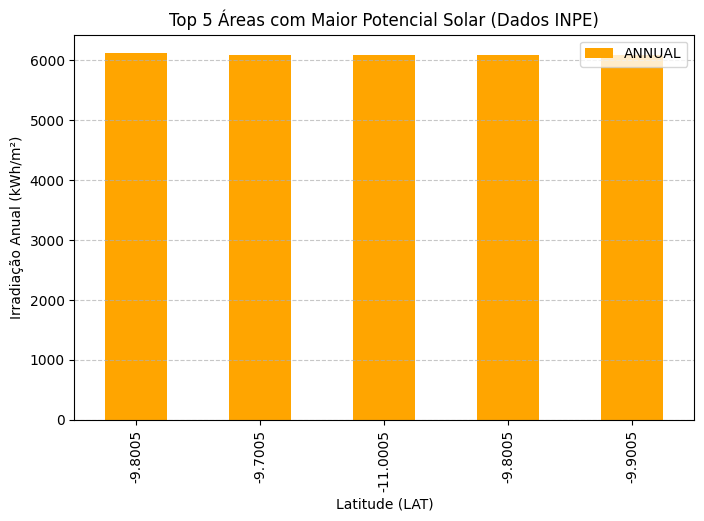

In [12]:
import matplotlib.pyplot as plt

# Criando um gráfico de barras com os top 5 resultados
top_5.plot(kind='bar', x='LAT', y='ANNUAL', color='orange', figsize=(8, 5))

plt.title('Top 5 Áreas com Maior Potencial Solar (Dados INPE)')
plt.ylabel('Irradiação Anual (kWh/m²)')
plt.xlabel('Latitude (LAT)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()